In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# -------------------------------------------------------------
# Directories
# -------------------------------------------------------------
DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)


# -------------------------------------------------------------
# Targets & Training Config
# -------------------------------------------------------------
TARGET_MAP = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

EXCLUDE = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]

WINDOW_SIZE = 1
BATCH_SIZE = 32
EPOCHS = 80
LR = 1e-4


# ============================================================
# 1. Load & preprocess dataset
# ============================================================

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    df = df.drop(columns=[c for c in EXCLUDE if c in df.columns], errors="ignore")
    df_num = df.select_dtypes(include=[np.number])

    target_cols = list(TARGET_MAP.values())
    feature_cols = [c for c in df_num.columns if c not in target_cols]

    X = df_num[feature_cols].fillna(0).values.astype(np.float32)
    y = {
        "Throughput": df_num[TARGET_MAP["Throughput"]].fillna(0).values.astype(np.float32),
        "Latency":    df_num[TARGET_MAP["Latency"]].fillna(0).values.astype(np.float32),
        "Loss":       df_num[TARGET_MAP["Loss"]].fillna(0).values.astype(np.float32),
    }
    return X, y, feature_cols


def make_sequence_dataset(X, y, window=1):
    N = len(X)
    if N == 0:
        return np.empty((0, window, X.shape[1])), np.empty((0,))
    return X.reshape(N, window, X.shape[1]), y.copy()


# ============================================================
# 2. Transformer Regression Model
# ============================================================

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, embed_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()

        self.embed = nn.Linear(input_dim, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, 1)

    def forward(self, x):  
        x = self.embed(x)         # (batch, seq, embed_dim)
        x = self.encoder(x)       # (batch, seq, embed_dim)
        x = x[:, -1, :]           # last token
        return self.fc_out(x)     # regression
        

# ============================================================
# 3. Train a single Transformer
# ============================================================

def train_single_transformer(X_train, y_train, X_valid, y_valid, model_name, input_dim):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TransformerRegressor(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    # Data loaders (no tqdm)
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1))
    valid_ds = TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid).unsqueeze(1))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

    best_loss = float("inf")
    patience = 0
    patience_limit = 8
    best_state = None

    print(f"\n=== Training Transformer-{model_name} ===")

    for epoch in range(1, EPOCHS + 1):

        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= max(1, len(train_loader))

        # ---------------- VALID ----------------
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                valid_loss += loss_fn(pred, yb).item()
        valid_loss /= max(1, len(valid_loader))

        # Clean single output line per epoch
        print(f"Epoch {epoch}/{EPOCHS} | Train={train_loss:.4f} | Valid={valid_loss:.4f}")

        # Early stopping
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_state = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= patience_limit:
                print("Early Stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Save model
    model_path = os.path.join(MODEL_DIR, f"transformer_model_{model_name.lower()}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"Saved → {model_path}")

    return model



# ============================================================
# 4. Prediction Function
# ============================================================

def predict_transformer(model, X):
    device = next(model.parameters()).device
    with torch.no_grad():
        return model(torch.tensor(X).to(device)).cpu().numpy().flatten()


# ============================================================
# 5. Full Transformer Training Pipeline
# ============================================================

def train_transformer_pipeline():

    df_train, df_valid, df_test = load_split_data()
    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _           = extract_xy(df_valid)
    X_test,  y_test_dict, _            = extract_xy(df_test)

    input_dim = X_train.shape[1]
    print(f"Transformer input_dim = {input_dim}")

    for target_name in ["Throughput", "Latency", "Loss"]:

        print(f"\n=== Transformer training for {target_name} ===")

        y_train = y_train_dict[target_name]
        y_valid = y_valid_dict[target_name]
        y_test  = y_test_dict[target_name]

        # reshape into 1-step sequences
        Xtr, ytr = make_sequence_dataset(X_train, y_train)
        Xva, yva = make_sequence_dataset(X_valid, y_valid)
        Xte, yte = make_sequence_dataset(X_test, y_test)

        if len(Xtr) == 0:
            print(f"[{target_name}] Skipping – no training samples.")
            continue

        model = train_single_transformer(Xtr, ytr, Xva, yva, target_name, input_dim)

        pred_valid = predict_transformer(model, Xva)
        pred_test  = predict_transformer(model, Xte)

        # Save predictions
        pd.DataFrame({"y_true": yva, "y_pred": pred_valid}).to_csv(
            os.path.join(PRED_DIR, f"transformer_{target_name}_valid_predictions.csv"),
            index=False
        )
        pd.DataFrame({"y_true": yte, "y_pred": pred_test}).to_csv(
            os.path.join(PRED_DIR, f"transformer_{target_name}_test_predictions.csv"),
            index=False
        )

        print(f"[Transformer-{target_name}] Saved predictions.")


# ============================================================
# 6. Run
# ============================================================

if __name__ == "__main__":
    train_transformer_pipeline()


Transformer input_dim = 103

=== Transformer training for Throughput ===

=== Training Transformer-Throughput ===
Epoch 1/80 | Train=0.0792 | Valid=0.0078
Epoch 2/80 | Train=0.0236 | Valid=0.0600
Epoch 3/80 | Train=0.0898 | Valid=0.0348
Epoch 4/80 | Train=0.0404 | Valid=0.0058
Epoch 5/80 | Train=0.0482 | Valid=0.0028
Epoch 6/80 | Train=0.0046 | Valid=0.0004
Epoch 7/80 | Train=0.0027 | Valid=0.0008
Epoch 8/80 | Train=0.0072 | Valid=0.0026
Epoch 9/80 | Train=0.0427 | Valid=0.0028
Epoch 10/80 | Train=0.0043 | Valid=0.0031
Epoch 11/80 | Train=0.0286 | Valid=0.0035
Epoch 12/80 | Train=0.0340 | Valid=0.0003
Epoch 13/80 | Train=0.0113 | Valid=0.0012
Epoch 14/80 | Train=0.0237 | Valid=0.0102
Epoch 15/80 | Train=0.0169 | Valid=0.0171
Epoch 16/80 | Train=0.0302 | Valid=0.0216
Epoch 17/80 | Train=0.0182 | Valid=0.0189
Epoch 18/80 | Train=0.0590 | Valid=0.0070
Epoch 19/80 | Train=0.0169 | Valid=0.0006
Epoch 20/80 | Train=0.0162 | Valid=0.0010
Early Stopping triggered.
Saved → ../outputs/models/tra

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PLOT_DIR = "../outputs/plots/transformer/"
os.makedirs(PLOT_DIR, exist_ok=True)

def plot_predicted_vs_actual(model_name, split="valid", showImage=False):
    """
    model_name: "Throughput", "Latency", "Loss"
    split:      "valid" or "test"
    showImage:  True → show plot, False → only save
    """

    pred_file = f"../outputs/models/predictions/transformer_{model_name}_{split}_predictions.csv"

    if not os.path.exists(pred_file):
        print(f"[WARN] Prediction file not found: {pred_file}")
        return

    df = pd.read_csv(pred_file)

    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    # -----------------------------
    # Scatter Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             "r--", label="Ideal")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Transformer {model_name} — Predicted vs Actual ({split})")
    plt.legend()

    out_path = os.path.join(PLOT_DIR, f"transformer_{model_name}_{split}_scatter.png")
    plt.savefig(out_path, dpi=200)
    print(f"[Transformer-{model_name}] Saved scatter plot → {out_path}")

    if showImage:
        plt.show()
    plt.close()

    # -----------------------------
    # Time-Series Plot
    # -----------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linewidth=2)
    plt.title(f"Transformer {model_name} — Time-Series ({split})")
    plt.xlabel("Sample Index")
    plt.ylabel(model_name)
    plt.legend()

    out_path_ts = os.path.join(PLOT_DIR, f"transformer_{model_name}_{split}_timeseries.png")
    plt.savefig(out_path_ts, dpi=200)
    print(f"[Transformer-{model_name}] Saved time-series plot → {out_path_ts}")

    if showImage:
        plt.show()
    plt.close()


[Transformer-Throughput] Saved scatter plot → ../outputs/plots/transformer/transformer_Throughput_test_scatter.png


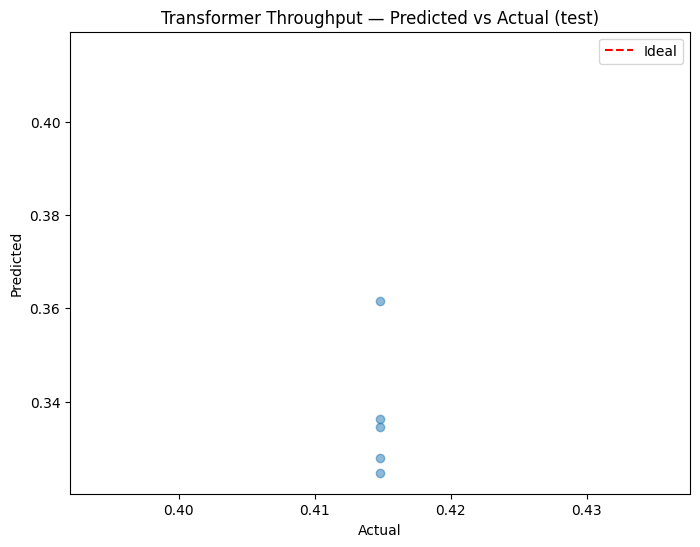

[Transformer-Throughput] Saved time-series plot → ../outputs/plots/transformer/transformer_Throughput_test_timeseries.png


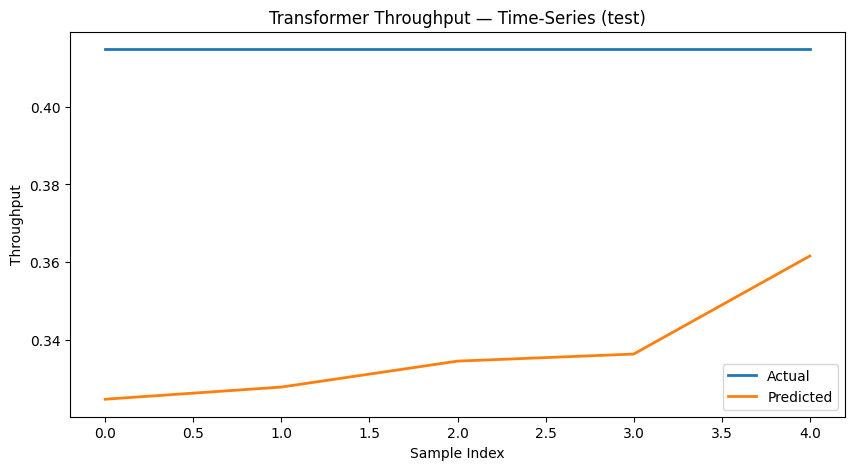

In [10]:
plot_predicted_vs_actual("Throughput", split="test", showImage=True)


In [7]:
plot_predicted_vs_actual("Latency", split="test", showImage=False)


[Transformer-Latency] Saved scatter plot → ../outputs/plots/transformer/transformer_Latency_test_scatter.png
[Transformer-Latency] Saved time-series plot → ../outputs/plots/transformer/transformer_Latency_test_timeseries.png


[Transformer-Loss] Saved scatter plot → ../outputs/plots/transformer/transformer_Loss_test_scatter.png


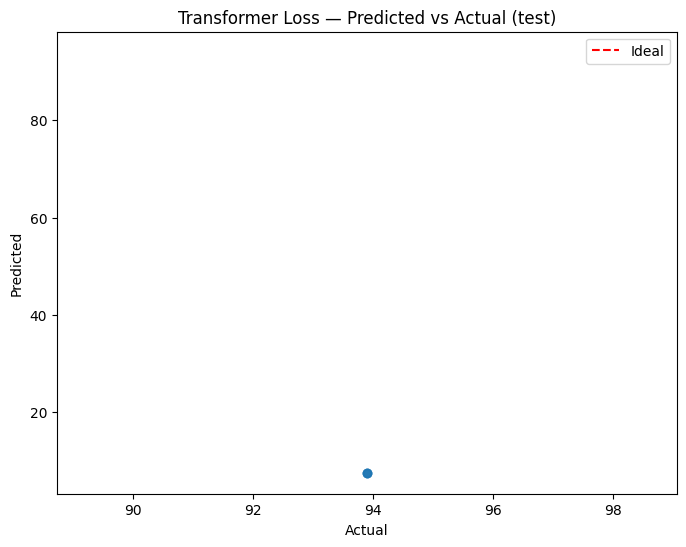

[Transformer-Loss] Saved time-series plot → ../outputs/plots/transformer/transformer_Loss_test_timeseries.png


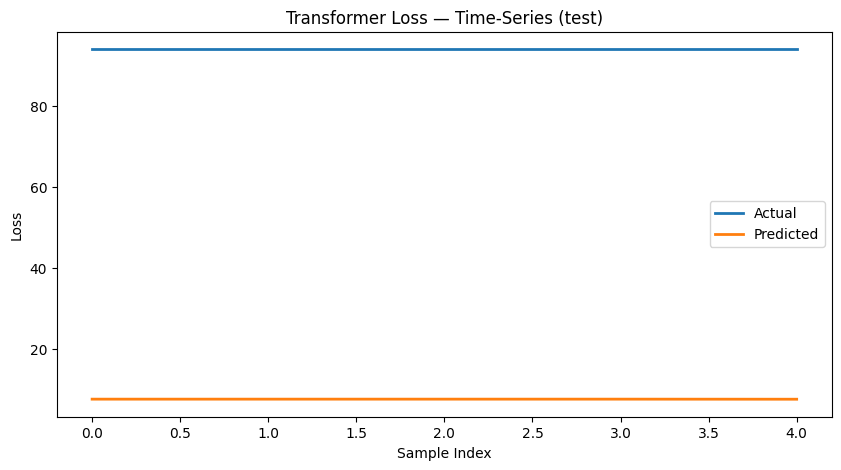

In [9]:
plot_predicted_vs_actual("Loss", split="test", showImage=True)


In [11]:
import os
import time
import torch
import torch.nn as nn
import numpy as np


# ================================================================
# Load Transformer Architecture (must match training)
# ================================================================

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, embed_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()

        self.input_dim = input_dim
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        self.embed = nn.Linear(input_dim, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embed(x)          # (batch, seq, embed_dim)
        x = self.encoder(x)        # (batch, seq, embed_dim)
        x = x[:, -1, :]            # last token for regression
        return self.fc_out(x)


# ================================================================
# Load saved transformer model
# ================================================================

def load_transformer_model(model_path, input_dim):
    model = TransformerRegressor(input_dim)
    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model


# ================================================================
# Parameter count + Model size
# ================================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model):
    return count_parameters(model) * 4    # FP32 = 4 bytes per param


# ================================================================
# FLOPs for Transformer Encoder (accurate analytical formula)
# ================================================================
"""
Transformer FLOPs (single encoder layer):

1. Multi-Head Self-Attention:
   - Q,K,V projection: 3 × (d_model × d_model)
   - Attention scores: seq_len² × d_model
   - Output projection: d_model × d_model

2. Feedforward Network (FFN):
   - First linear: d_model × (4*d_model)
   - Second linear: (4*d_model) × d_model

Total FLOPs per layer:
   FLOPs = attention_FLOPs + FFN_FLOPs
"""

def compute_transformer_flops(model, sequence_len=1):

    d_model = model.embed_dim
    num_layers = model.num_layers
    heads = model.num_heads

    # Self-attention FLOPs
    flops_attention = (
        3 * (d_model * d_model) +
        (sequence_len * sequence_len * d_model) + 
        (d_model * d_model)
    )

    # FFN FLOPs
    d_ff = d_model * 4
    flops_ffn = (d_model * d_ff) + (d_ff * d_model)

    flops_per_layer = flops_attention + flops_ffn

    total_flops = num_layers * flops_per_layer + (2 * d_model)  # FC head

    return total_flops


# ================================================================
# Latency measurement
# ================================================================

def measure_latency(model, example_input, runs=200, warmup=20):
    device = "cpu"
    model.to(device)
    example_input = example_input.to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(example_input)

    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(example_input)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


# ================================================================
# Energy estimate (power × latency)
# ================================================================

def estimate_energy(latency_s, power_W=2.0):
    return latency_s * power_W


# ================================================================
# Peak activation memory (output tensor size)
# ================================================================

def estimate_peak_activation_memory(model, example_input):
    with torch.no_grad():
        out = model(example_input)
    return out.numel() * 4  # FP32 bytes


# ================================================================
# Full Transformer Edge Evaluation
# ================================================================

def evaluate_transformer_edge(model_path, input_dim, sequence_len=1, assumed_power_W=2.0):

    model = load_transformer_model(model_path, input_dim)

    example_input = torch.randn(1, sequence_len, input_dim)

    params = count_parameters(model)
    size_b = model_size_bytes(model)
    size_mb = size_b / (1024 * 1024)

    flops = compute_transformer_flops(model, sequence_len)
    latency_s = measure_latency(model, example_input)
    latency_ms = latency_s * 1000

    energy = estimate_energy(latency_s, assumed_power_W)
    peak_mem = estimate_peak_activation_memory(model, example_input)

    return {
        "Model Path": model_path,
        "Parameters": params,
        "Model Size (Bytes)": size_b,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (s)": latency_s,
        "Latency (ms)": latency_ms,
        "Estimated Energy (J)": energy,
        "Peak Activation Memory (Bytes)": peak_mem
    }


In [12]:
# from transformer_edge_evaluation import evaluate_transformer_edge

input_dim = 103   # same as training
model_path = "../outputs/models/transformer_model_throughput.pt"

metrics = evaluate_transformer_edge(model_path, input_dim)

for k, v in metrics.items():
    print(f"{k}: {v}")


Model Path: ../outputs/models/transformer_model_throughput.pt
Parameters: 409985
Model Size (Bytes): 1639940
Model Size (MB): 1.5639686584472656
FLOPs: 393728
Latency (s): 0.0014835075003793463
Latency (ms): 1.4835075003793463
Estimated Energy (J): 0.0029670150007586925
Peak Activation Memory (Bytes): 4
